# 📊 Telecom Churn Analysis using SageMaker Canvas


## 📌 Overview
This project builds a churn prediction pipeline using Amazon SageMaker Canvas.

The workflow includes:
- Data cleaning (Canvas)
- Feature engineering (PySpark)
- Class imbalance handling (SMOTE)
- Model training (Canvas AutoML)


## 📊 Pipeline Overview

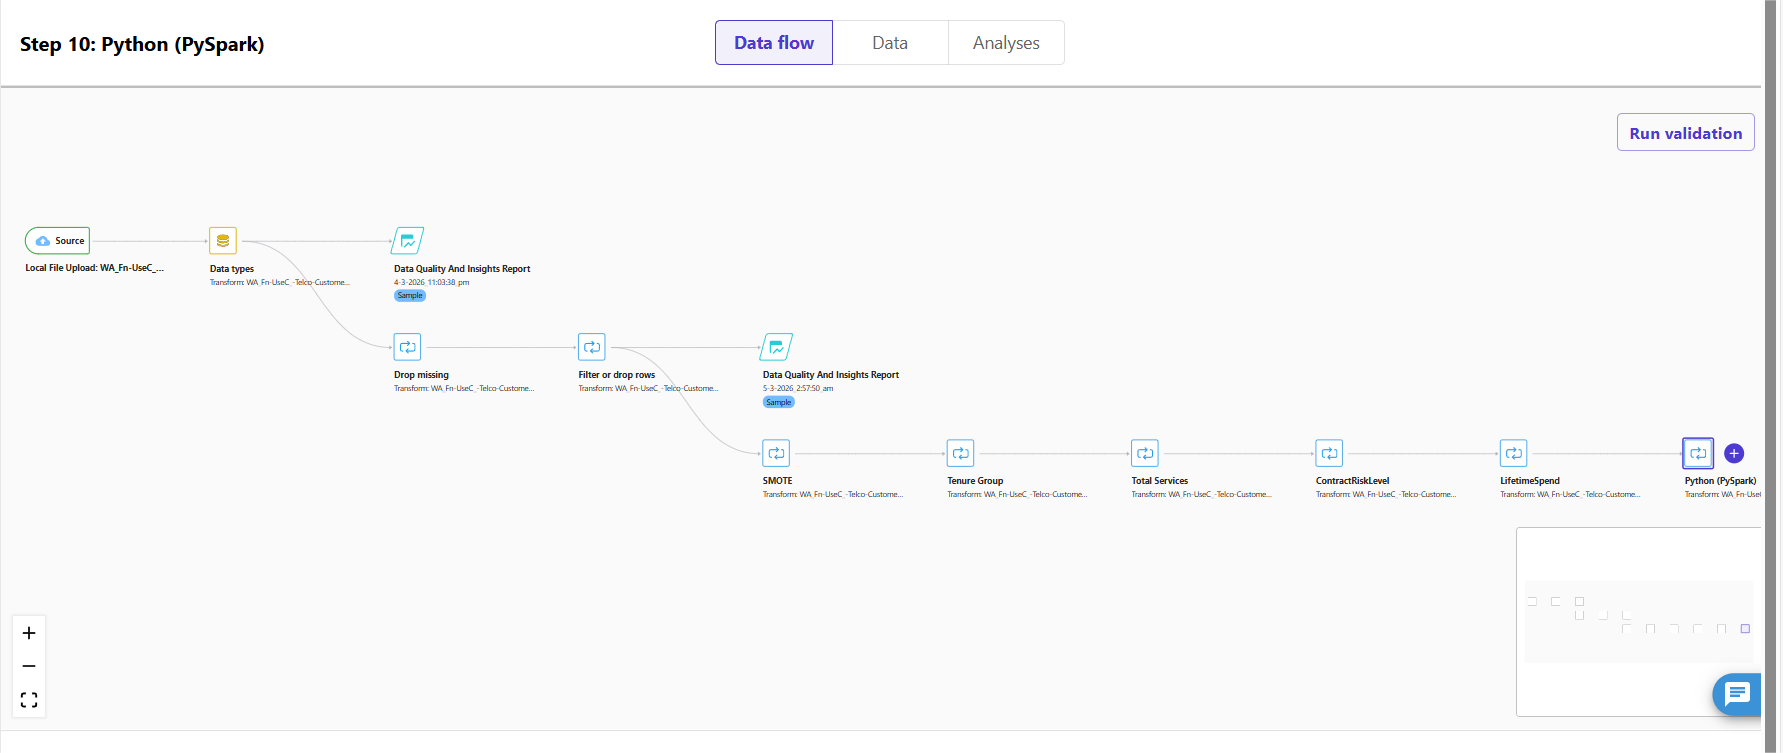


### Explanation
The pipeline was created using SageMaker Canvas, applying sequential transformations and validations before model training.


## 🧹 Data Cleaning

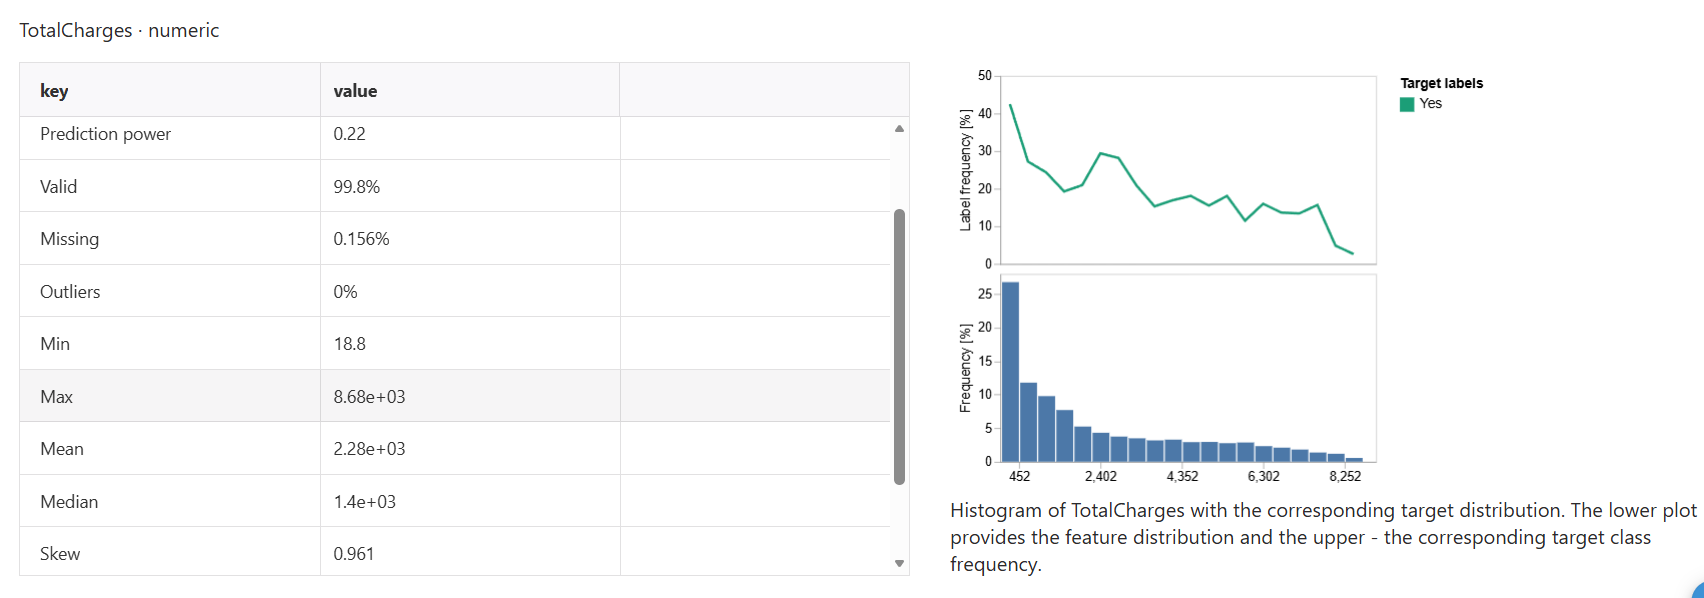


### Steps Performed
- Removed missing values
- Filtered invalid rows


## ⚖️ Class Imbalance Handling

##### Theres a class Imbalace

![SMOTE](assets/feature_summary.png)


### Explanation
SMOTE was applied to balance the dataset and improve model performance.


## ⚙️ Feature Engineering

**ContractRiskLevel**

In [ ]:

from pyspark.sql.functions import col, when

df = df.withColumn(
    "ContractRiskLevel",
    when(col("Contract") == "Month-to-month", 3)
    .when(col("Contract") == "One year", 2)
    .when(col("Contract") == "Two year", 1)
)

df

**TenureGroup**

In [ ]:

from pyspark.sql.functions import when, col

df = df.withColumn(
    "TenureGroup",
    when(col("tenure") < 12, "0-1 Year")
    .when(col("tenure") < 24, "1-2 Years")
    .otherwise("2+ Years")
)

**TotalServices**

In [ ]:

from pyspark.sql.functions import col, when

df = df.withColumn(
    "TotalServices",
      when(col("PhoneService") == "Yes", 1).otherwise(0)
    + when(col("MultipleLines") == "Yes", 1).otherwise(0)
    + when(col("OnlineSecurity") == "Yes", 1).otherwise(0)
    + when(col("OnlineBackup") == "Yes", 1).otherwise(0)
    + when(col("DeviceProtection") == "Yes", 1).otherwise(0)
    + when(col("TechSupport") == "Yes", 1).otherwise(0)
    + when(col("StreamingTV") == "Yes", 1).otherwise(0)
    + when(col("StreamingMovies") == "Yes", 1).otherwise(0)
)

df

**LifetimeSpend**

In [ ]:

df = df.withColumn(
    "LifetimeSpend",
    col("tenure") * col("MonthlyCharges")
)

## 📊 Exploratory Data Analysis

**Basic Statistics**

In [ ]:
df.describe().show()

**Class Distribution**

In [ ]:
df.groupBy("Churn").count().show()

**Correlation Insights**

In [ ]:
import pyspark.sql.functions as F

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df.select(numeric_cols).summary().show()


### Insights
- Customers with shorter tenure are more likely to churn
- Monthly charges influence churn behavior


## 🤖 Model Training

![Model](assets/quick_model.png)


### Explanation
Model training was performed using SageMaker Canvas AutoML, which selected the best model automatically.


## 📈 Model Evaluation

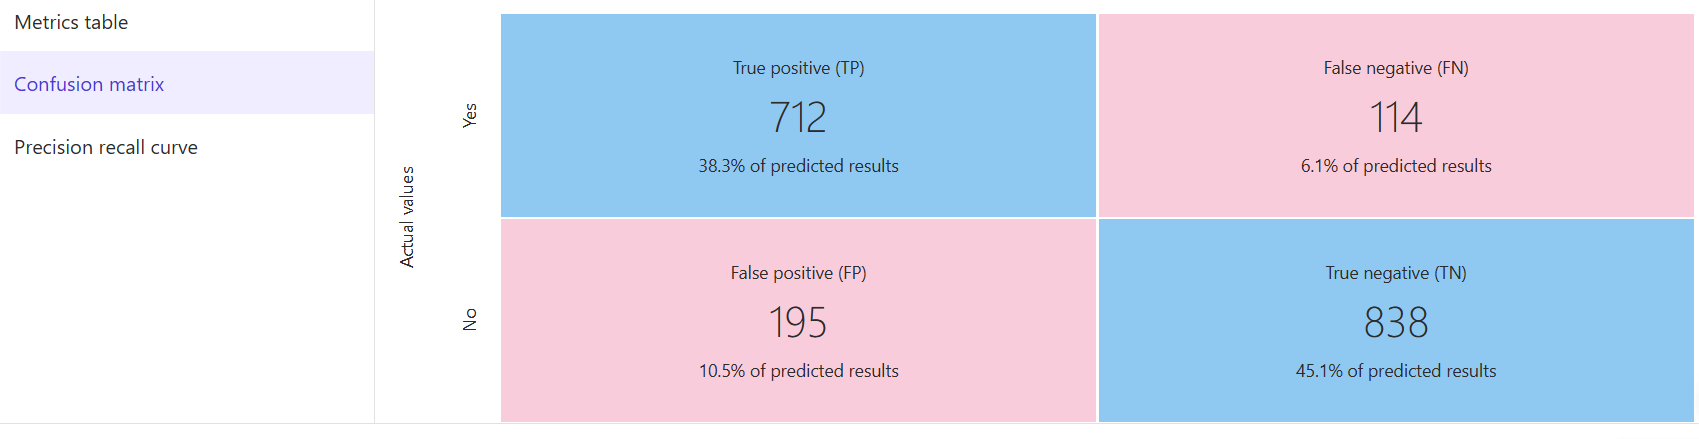

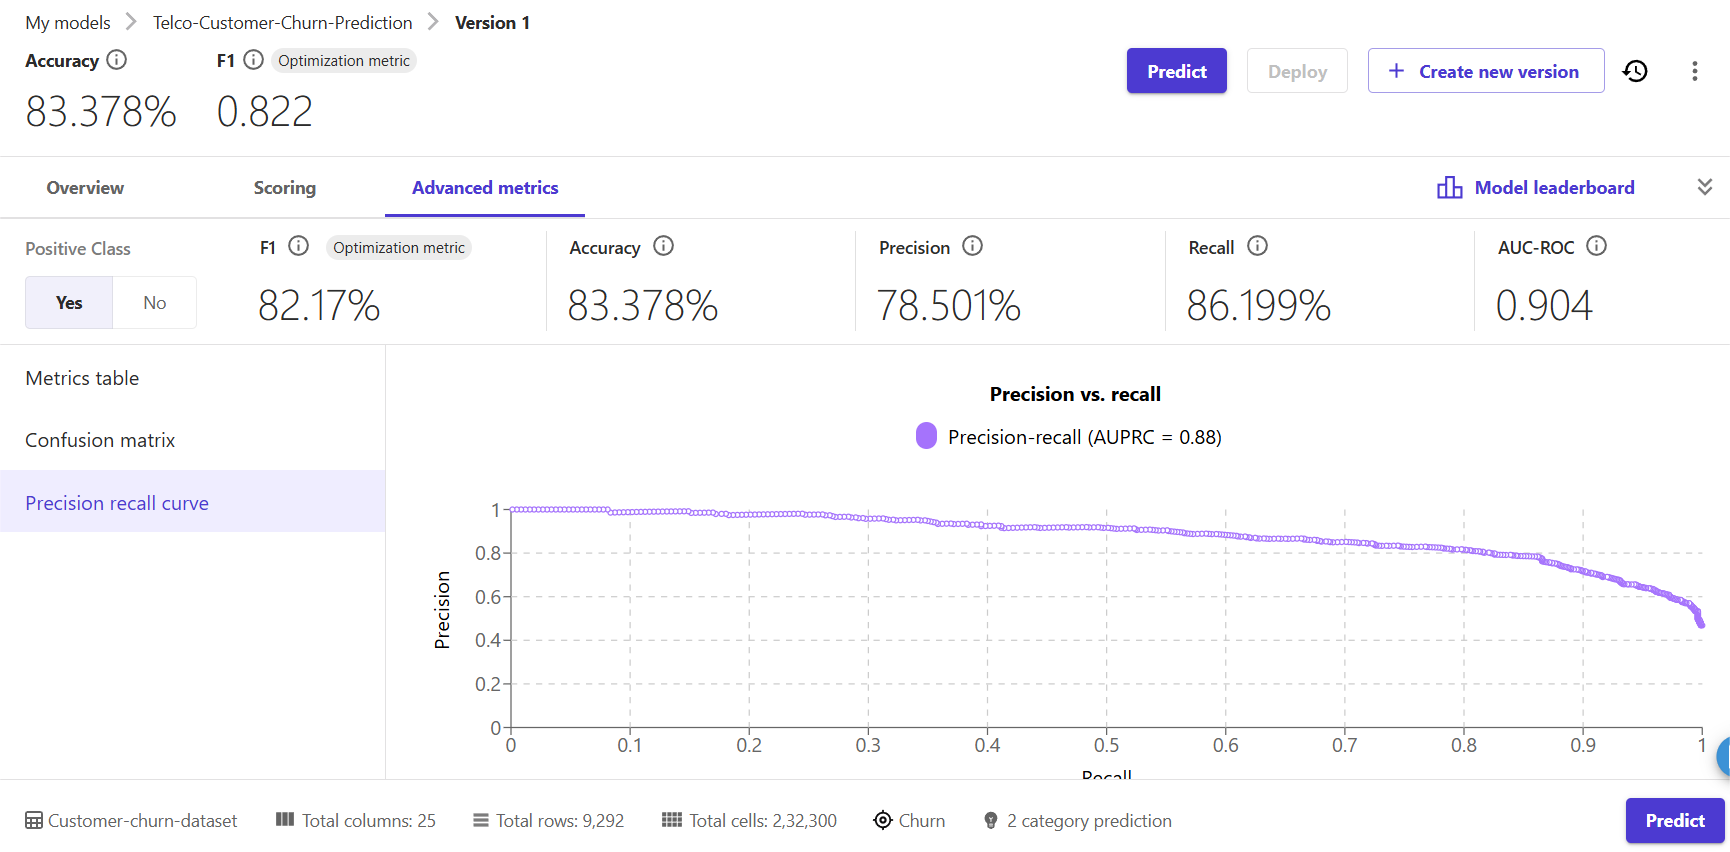


## ✅ Conclusion
- Built an end-to-end churn prediction pipeline
- Combined no-code Canvas workflow with PySpark feature engineering
- Achieved a structured and scalable ML pipeline
